# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 70s 0us/step
Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## 🖼️ Visualize Sample Images

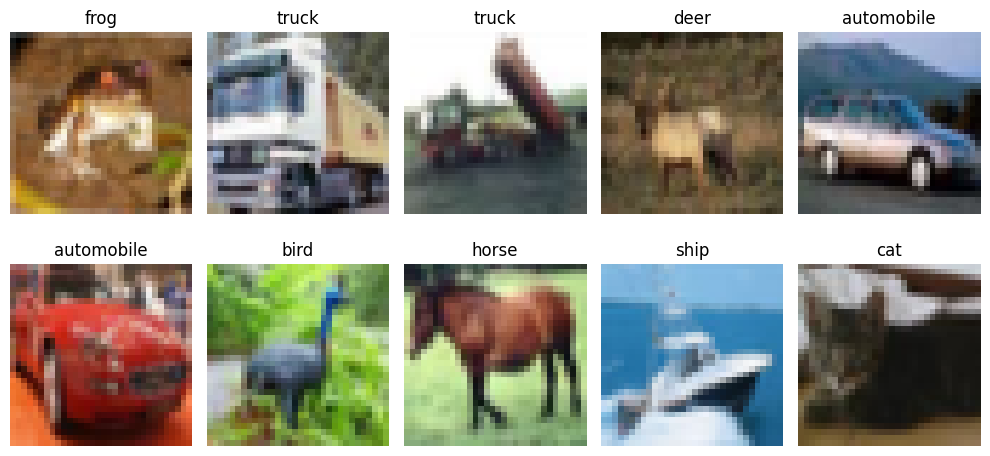

In [3]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [4]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [5]:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 26s 35ms/step - accuracy: 0.2753 - loss: 1.9874 - val_accuracy: 0.3514 - val_loss: 1.8004
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 37s 30ms/step - accuracy: 0.3227 - loss: 1.8564 - val_accuracy: 0.3572 - val_loss: 1.7766
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 29ms/step - accuracy: 0.3469 - loss: 1.7968 - val_accuracy: 0.3886 - val_loss: 1.7174
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 31ms/step - accuracy: 0.3656 - loss: 1.7476 - val_accuracy: 0.4016 - val_loss: 1.6810
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 40s 30ms/step - accuracy: 0.3723 - loss: 1.7306 - val_accuracy: 0.4004 - val_loss: 1.6749
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 31ms/step - accuracy: 0.3798 - loss: 1.7047 - val_accuracy: 0.4070 - val_loss: 1.6641
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - accuracy: 0.3872 - loss: 1.6896 - val_accuracy: 0.4234 - val_loss: 1.6440
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.3926 - loss: 1.6739 - 

In [6]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.4305 - loss: 1.6243
ANN Test Accuracy: 0.43050000071525574


# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [7]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 91s 125ms/step - accuracy: 0.4744 - loss: 1.4684 - val_accuracy: 0.5562 - val_loss: 1.2457
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 88s 125ms/step - accuracy: 0.6149 - loss: 1.0988 - val_accuracy: 0.6014 - val_loss: 1.1140
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 84s 120ms/step - accuracy: 0.6789 - loss: 0.9272 - val_accuracy: 0.6160 - val_loss: 1.1486
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 143s 121ms/step - accuracy: 0.7147 - loss: 0.8224 - val_accuracy: 0.6730 - val_loss: 0.9405
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 85s 120ms/step - accuracy: 0.7483 - loss: 0.7251 - val_accuracy: 0.6110 - val_loss: 1.2695
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 86s 122ms/step - accuracy: 0.7746 - loss: 0.6462 - val_accuracy: 0.6626 - val_loss: 0.9924
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 85s 121ms/step - accuracy: 0.7956 - loss: 0.5777 - val_accuracy: 0.6348 - val_loss: 1.1497
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 87s 123ms/step - accuracy: 0.8162 - loss: 

In [8]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.6918 - loss: 1.0405
CNN Test Accuracy: 0.6917999982833862


In [ ]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    # Added layers to fix the error and complete the classification model
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 52s 71ms/step - accuracy: 0.4474 - loss: 1.5685 - val_accuracy: 0.4554 - val_loss: 1.5801
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 81s 70ms/step - accuracy: 0.5636 - loss: 1.2305 - val_accuracy: 0.5966 - val_loss: 1.1539
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 50s 71ms/step - accuracy: 0.6151 - loss: 1.0898 - val_accuracy: 0.6312 - val_loss: 1.0835
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 49s 70ms/step - accuracy: 0.6517 - loss: 0.9826 - val_accuracy: 0.5934 - val_loss: 1.2121
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 49s 70ms/step - accuracy: 0.6852 - loss: 0.8899 - val_accuracy: 0.5556 - val_loss: 1.4763
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 49s 70ms/step - accuracy: 0.7128 - loss: 0.8119 - val_accuracy: 0.6162 - val_loss: 1.1902
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 48s 68ms/step - accuracy: 0.7341 - loss: 0.7469 - val_accuracy: 0.6530 - val_loss: 1.0462
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 49s 70ms/step - accuracy: 0.7596 - loss: 0.6781 - 

In [ ]:
cnn_model = models.Sequential([
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 92s 127ms/step - accuracy: 0.4638 - loss: 1.5250 - val_accuracy: 0.5414 - val_loss: 1.2542
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 144s 130ms/step - accuracy: 0.5719 - loss: 1.2110 - val_accuracy: 0.5928 - val_loss: 1.1540
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 90s 128ms/step - accuracy: 0.6238 - loss: 1.0659 - val_accuracy: 0.6206 - val_loss: 1.0692
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 140s 125ms/step - accuracy: 0.6623 - loss: 0.9530 - val_accuracy: 0.5682 - val_loss: 1.3427
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 88s 125ms/step - accuracy: 0.6968 - loss: 0.8629 - val_accuracy: 0.6568 - val_loss: 1.0204
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 142s 125ms/step - accuracy: 0.7232 - loss: 0.7773 - val_accuracy: 0.6546 - val_loss: 1.0241
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 144s 127ms/step - accuracy: 0.7484 - loss: 0.7070 - val_accuracy: 0.6472 - val_loss: 1.0917
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 88s 125ms/step - accuracy: 0.7702 - los

In [9]:
cnn_model = models.Sequential([
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 268s 378ms/step - accuracy: 0.3758 - loss: 1.7220 - val_accuracy: 0.4980 - val_loss: 1.3855
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 254s 360ms/step - accuracy: 0.4730 - loss: 1.4470 - val_accuracy: 0.5396 - val_loss: 1.3058
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 260s 369ms/step - accuracy: 0.5162 - loss: 1.3378 - val_accuracy: 0.5592 - val_loss: 1.2238
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 269s 382ms/step - accuracy: 0.5450 - loss: 1.2520 - val_accuracy: 0.5912 - val_loss: 1.1782
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 253s 359ms/step - accuracy: 0.5778 - loss: 1.1651 - val_accuracy: 0.5990 - val_loss: 1.1599
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 263s 361ms/step - accuracy: 0.5985 - loss: 1.0952 - val_accuracy: 0.6044 - val_loss: 1.1455
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 261s 360ms/step - accuracy: 0.6220 - loss: 1.0335 - val_accuracy: 0.6066 - val_loss: 1.1490
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 263s 362ms/step - accuracy: 0.6476 -

In [10]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# EarlyStopping callback
early_stopping_callback = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stopping_callback]
)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 91s 124ms/step - accuracy: 0.4742 - loss: 1.4696 - val_accuracy: 0.5224 - val_loss: 1.3103
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 143s 125ms/step - accuracy: 0.6127 - loss: 1.1076 - val_accuracy: 0.5494 - val_loss: 1.3240
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 143s 126ms/step - accuracy: 0.6733 - loss: 0.9348 - val_accuracy: 0.6454 - val_loss: 1.0264
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 92s 131ms/step - accuracy: 0.7155 - loss: 0.8168 - val_accuracy: 0.6334 - val_loss: 1.0573
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 137s 124ms/step - accuracy: 0.7478 - loss: 0.7232 - val_accuracy: 0.6980 - val_loss: 0.9341
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 86s 122ms/step - accuracy: 0.7749 - loss: 0.6456 - val_accuracy: 0.6478 - val_loss: 1.1218
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 88s 125ms/step - accuracy: 0.7952 - loss: 0.5777 - val_accuracy: 0.6772 - val_loss: 0.9764
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 86s 122ms/step - accuracy: 0.8159 - loss

In [11]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.7243 - loss: 0.9054
CNN Test Accuracy: 0.7243000268936157


## 📈 Compare Learning Curves

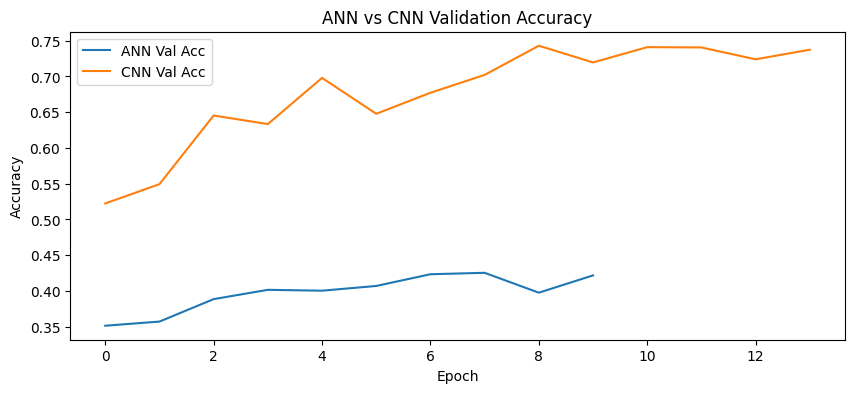

In [12]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.show()

# 🚀 Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

In [13]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

aug_cnn_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, 3, activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

# EarlyStopping callback
aug_early_stopping_callback = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)


aug_history = aug_cnn_model.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[aug_early_stopping_callback]
)

# Evaluating the augmented CNN model
aug_cnn_test_loss, aug_cnn_test_acc = aug_cnn_model.evaluate(x_test_norm, y_test)
print("Augmented CNN Test Accuracy:", aug_cnn_test_acc)


Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 68s 94ms/step - accuracy: 0.3677 - loss: 1.7336 - val_accuracy: 0.4668 - val_loss: 1.4706
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 66s 94ms/step - accuracy: 0.4614 - loss: 1.4904 - val_accuracy: 0.5518 - val_loss: 1.2474
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 81s 93ms/step - accuracy: 0.5022 - loss: 1.3969 - val_accuracy: 0.5652 - val_loss: 1.2348
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 81s 92ms/step - accuracy: 0.5256 - loss: 1.3357 - val_accuracy: 0.5992 - val_loss: 1.1302
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 65s 92ms/step - accuracy: 0.5453 - loss: 1.2838 - val_accuracy: 0.6044 - val_loss: 1.0870
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 65s 92ms/step - accuracy: 0.5581 - loss: 1.2548 - val_accuracy: 0.6016 - val_loss: 1.1449
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 64s 91ms/step - accuracy: 0.5683 - loss: 1.2256 - val_accuracy: 0.6336 - val_loss: 1.0391
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 83s 93ms/step - accuracy: 0.5767 - loss: 1.2018 - 

# 📊 Final Comparison Table

In [14]:
comparison = pd.DataFrame({
    "Model": ["ANN", "CNN", "Augmented CNN"], # Added "Augmented CNN"
    "Test Accuracy": [ann_test_acc, cnn_test_acc, aug_cnn_test_acc] # Added aug_cnn_test_acc
})
comparison

,Model,Test Accuracy
0,ANN,0.4305
1,CNN,0.7243
2,Augmented CNN,0.6778


# 🎓 Student Learning Tasks
Try these tasks after understanding the notebook:

### ✅ Beginner Tasks
1. Increase ANN layers and observe performance
2. Change CNN filters from 32→64→128
3. Increase epochs to 20
4. Add **EarlyStopping**
5. Add **data augmentation training**

# ✅ Conclusion
- **ANN works**, but ignores image structure
- **CNN extracts spatial features**, so it performs significantly better
- **Training strategies** like dropout, batch norm, and augmentation improve results
- This project builds strong fundamentals for **computer vision interviews and deep learning projects**